# NB3 — DPO Training (the main event)

**Stack:** TRL `DPOTrainer` + `DPOConfig(beta=0.1, lr=5e-7)` from deck §5.2.
Maps to deck §3 (DPO derivation), §3.4 (failure modes — read closely!), §5.2 (TRL impl).

> **Mục tiêu:** train DPO adapter on top of NB1 SFT-mini. Plot reward curves
> (cả `chosen_rewards` và `rejected_rewards`). Save adapter to `adapters/dpo/`.
>
> Đây là **the** notebook quan trọng nhất của lab — 25/100 pts đến từ đây.
> Đặc biệt là: **plot cả 2 curve riêng biệt**, không chỉ reward gap (deck §3.4).

## 0. Setup

In [1]:
import os
import time
from pathlib import Path

COMPUTE_TIER = os.environ.get("COMPUTE_TIER", "T4").upper()
assert COMPUTE_TIER in ("LOWVRAM", "T4", "BIGGPU"), f"Invalid COMPUTE_TIER: {COMPUTE_TIER}"

if COMPUTE_TIER == "LOWVRAM":
    BASE_MODEL = os.environ.get("BASE_MODEL", "Qwen/Qwen2.5-0.5B-Instruct")
    MAX_LEN = int(os.environ.get("MAX_LEN", "192"))
    MAX_PROMPT_LEN = int(os.environ.get("MAX_PROMPT_LEN", "96"))
    PER_DEVICE_BATCH = 1
    GRAD_ACCUM = 4
elif COMPUTE_TIER == "T4":
    BASE_MODEL = "unsloth/Qwen2.5-3B-bnb-4bit"
    MAX_LEN = 512
    MAX_PROMPT_LEN = 256
    PER_DEVICE_BATCH = 1
    GRAD_ACCUM = 8
else:
    BASE_MODEL = "unsloth/Qwen2.5-7B-bnb-4bit"
    MAX_LEN = 1024
    MAX_PROMPT_LEN = 512
    PER_DEVICE_BATCH = 1
    GRAD_ACCUM = 4

# Hyperparameters from deck §5.2 (TRL DPOTrainer implementation frame)
BETA = float(os.environ.get("DPO_BETA", "0.1"))
# A 128-pair, 0.5B run needs a stronger update than the full 1k/5k-pair tiers;
# the first LOWVRAM baseline at 5e-7 produced a noisy negative final margin.
default_lr = "5e-6" if COMPUTE_TIER == "LOWVRAM" else "5e-7"
default_epochs = "2" if COMPUTE_TIER == "LOWVRAM" else "1"
LR = float(os.environ.get("DPO_LR", default_lr))
EPOCHS = int(os.environ.get("DPO_EPOCHS", default_epochs))

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SFT_PATH = REPO_ROOT / "adapters" / "sft-mini"
DPO_OUT = REPO_ROOT / "adapters" / "dpo"
PREF_PATH = REPO_ROOT / "data" / "pref" / "train.parquet"

DPO_OUT.mkdir(parents=True, exist_ok=True)

assert SFT_PATH.exists(), f"NB1 must run first — {SFT_PATH} missing"
assert PREF_PATH.exists(), f"NB2 must run first — {PREF_PATH} missing"

print(f"COMPUTE_TIER:    {COMPUTE_TIER}")
print(f"BASE_MODEL:      {BASE_MODEL}")
print(f"DPO hyperparams: beta={BETA}  lr={LR}  epochs={EPOCHS}")
print(f"max_length:      {MAX_LEN}  (prompt={MAX_PROMPT_LEN})")
print(f"effective batch: {PER_DEVICE_BATCH * GRAD_ACCUM}")
print(f"SFT input:       {SFT_PATH}")
print(f"output:          {DPO_OUT}")

COMPUTE_TIER:    LOWVRAM
BASE_MODEL:      Qwen/Qwen2.5-0.5B-Instruct
DPO hyperparams: beta=0.1  lr=5e-06  epochs=2
max_length:      192  (prompt=96)
effective batch: 4
SFT input:       C:\Users\Laptop\OneDrive\Laptop\WorkSpace\VinAI\Session\Day22-Track3-DPO-Alignment-Lab\adapters\sft-mini
output:          C:\Users\Laptop\OneDrive\Laptop\WorkSpace\VinAI\Session\Day22-Track3-DPO-Alignment-Lab\adapters\dpo


In [2]:
import torch

assert torch.cuda.is_available(), "DPO needs a CUDA GPU. See HARDWARE-GUIDE.md."
torch.cuda.reset_peak_memory_stats()

## 1. Load policy + reference (the VRAM story)

**Critical:** DPO scores each answer under the policy (trainable) AND a frozen
reference. With PEFT we do **not** load a second model -- TRL toggles the LoRA
adapter *off* to get the reference forward pass on the same 4-bit base. The
extra VRAM vs SFT comes from two forward passes + holding chosen AND rejected
sequences, not from a second copy of the weights.

In [3]:
from peft import LoraConfig, PeftModel, get_peft_model

# Merge the frozen SFT update into the base first, then attach a fresh DPO LoRA.
# With ref_model=None, TRL disables only that fresh adapter for the reference
# forward pass, so the actual reference policy is SFT (not the original base).
if COMPUTE_TIER == "LOWVRAM":
    from transformers import AutoModelForCausalLM, AutoTokenizer

    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
    model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL,
        torch_dtype=torch.float16,
        low_cpu_mem_usage=True,
    ).to("cuda")
else:
    from unsloth import FastLanguageModel

    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=BASE_MODEL,
        max_seq_length=MAX_LEN,
        dtype=None,
        load_in_4bit=True,
    )
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = PeftModel.from_pretrained(model, str(SFT_PATH), is_trainable=False)
model = model.merge_and_unload(safe_merge=True)
print(f"Reference policy: SFT adapter merged into {model.__class__.__name__}")

C:\Users\Laptop\OneDrive\Laptop\WorkSpace\VinAI\Session\Day22-Track3-DPO-Alignment-Lab\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


`torch_dtype` is deprecated! Use `dtype` instead!


Reference policy: SFT adapter merged into Qwen2ForCausalLM


In [4]:
target_modules = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj",
]
if COMPUTE_TIER == "LOWVRAM":
    model.config.use_cache = False
    model.gradient_checkpointing_enable(
        gradient_checkpointing_kwargs={"use_reentrant": False}
    )
    model = get_peft_model(
        model,
        LoraConfig(
            task_type="CAUSAL_LM",
            r=16,
            lora_alpha=32,
            lora_dropout=0.0,
            bias="none",
            target_modules=target_modules,
        ),
    )
    model.enable_input_require_grads()
else:
    model = FastLanguageModel.get_peft_model(
        model,
        r=16,
        lora_alpha=32,
        lora_dropout=0.0,
        bias="none",
        target_modules=target_modules,
        use_gradient_checkpointing="unsloth",
        random_state=42,
        use_rslora=False,
        loftq_config=None,
    )
print(f"Trainable params (DPO LoRA): {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Trainable params (DPO LoRA): 8,798,208


> **Why no separate `ref_model=` argument?** Modern TRL (≥ 0.12) auto-detects
> PEFT models and disables the trainable DPO adapter for the reference pass.
> Here that underlying base already contains the merged SFT update, so the
> reference is exactly the SFT policy. No deepcopy is needed.

## 2. Build DPOConfig (deck §5.2 hyperparameters)

In [5]:
from trl import DPOConfig

dpo_config = DPOConfig(
    output_dir=str(DPO_OUT.parent / "dpo-checkpoints"),
    per_device_train_batch_size=PER_DEVICE_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    num_train_epochs=EPOCHS,
    learning_rate=LR,
    beta=BETA,
    max_length=MAX_LEN,
    max_prompt_length=MAX_PROMPT_LEN,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    logging_steps=2 if COMPUTE_TIER == "LOWVRAM" else 10,
    save_strategy="no",
    optim="adamw_torch" if COMPUTE_TIER == "LOWVRAM" else "adamw_8bit",
    bf16=torch.cuda.is_bf16_supported(),
    fp16=not torch.cuda.is_bf16_supported(),
    gradient_checkpointing=COMPUTE_TIER == "LOWVRAM",
    gradient_checkpointing_kwargs={"use_reentrant": False},
    seed=42,
    loss_type="sigmoid",         # DPO standard (alternatives: ipo, hinge, kto)
    report_to="none",
)

print(f"DPOConfig: beta={dpo_config.beta}  lr={dpo_config.learning_rate}  loss_type={dpo_config.loss_type}")

DPOConfig: beta=0.1  lr=5e-06  loss_type=sigmoid

## 3. Load preference data

In [6]:
from datasets import Dataset

pref_ds = Dataset.from_parquet(str(PREF_PATH))
print(f"Loaded {len(pref_ds)} preference pairs from {PREF_PATH}")
print(f"Columns: {pref_ds.column_names}")

Loaded 128 preference pairs from C:\Users\Laptop\OneDrive\Laptop\WorkSpace\VinAI\Session\Day22-Track3-DPO-Alignment-Lab\data\pref\train.parquet
Columns: ['prompt', 'chosen', 'rejected']


## 4. Train

In [7]:
from trl import DPOTrainer

trainer = DPOTrainer(
    model=model,
    ref_model=None,                # auto-derived from PEFT base
    args=dpo_config,
    train_dataset=pref_ds,
    processing_class=tokenizer,
)

In [8]:
started_at = time.perf_counter()
train_result = trainer.train()
training_seconds = time.perf_counter() - started_at
print(f"\nFinal DPO loss: {train_result.training_loss:.4f}")
print(f"Training time: {training_seconds / 60:.2f} min")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
2,0.693100
4,0.689400
6,0.701000
8,0.697800
10,0.669800
12,0.688900
14,0.686700
16,0.675100
18,0.685500
20,0.679200



Final DPO loss: 0.6713
Training time: 12.15 min


## 5. Plot reward curves — THE diagnostic

**Read deck §3.4 before interpreting these.** A growing reward gap can come from:
- **(intended)** chosen reward going up + rejected staying flat
- **(intended)** chosen rising slowly + rejected falling fast
- **(likelihood displacement)** chosen reward going *down* + rejected falling faster

The third case is what Razin et al. 2024 documented. It's not a bug, but it
tells you the model is finding a way to widen the gap that doesn't necessarily
improve actual chosen probability.

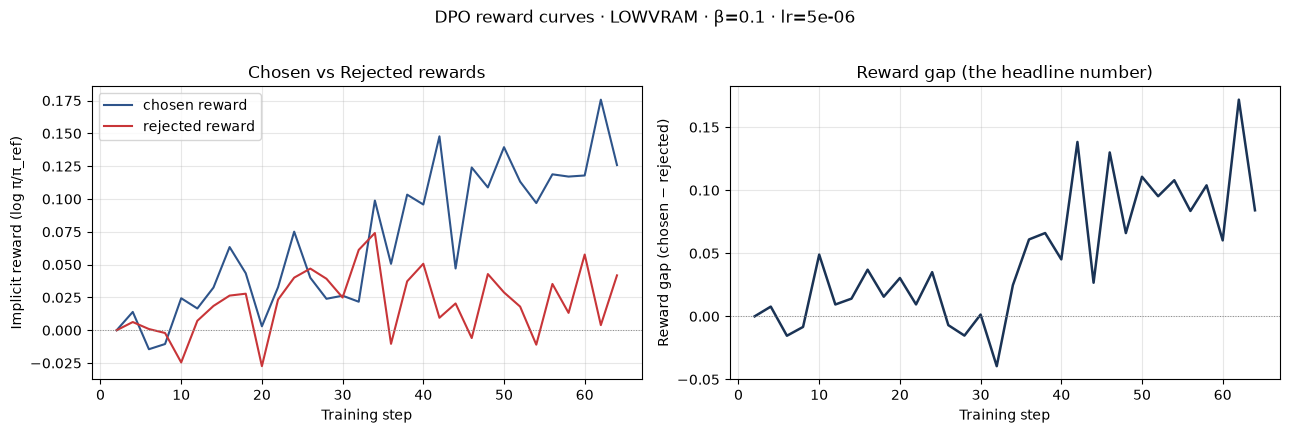

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

logs = pd.DataFrame(trainer.state.log_history)
if "loss" in logs.columns:
    logs = logs[logs["loss"].notna()].copy()

# TRL DPO logs include rewards/chosen, rewards/rejected, rewards/margins, kl
chosen_col = "rewards/chosen" if "rewards/chosen" in logs.columns else None
rejected_col = "rewards/rejected" if "rewards/rejected" in logs.columns else None

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

if chosen_col and rejected_col:
    axes[0].plot(logs["step"], logs[chosen_col], label="chosen reward", color="#2e548a", linewidth=1.5)
    axes[0].plot(logs["step"], logs[rejected_col], label="rejected reward", color="#c83538", linewidth=1.5)
    axes[0].axhline(0, color="#888", linestyle=":", linewidth=0.7)
    axes[0].set_xlabel("Training step")
    axes[0].set_ylabel("Implicit reward (log π/π_ref)")
    axes[0].set_title("Chosen vs Rejected rewards")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    gap = logs[chosen_col] - logs[rejected_col]
    axes[1].plot(logs["step"], gap, color="#1a3355", linewidth=1.8)
    axes[1].axhline(0, color="#888", linestyle=":", linewidth=0.7)
    axes[1].set_xlabel("Training step")
    axes[1].set_ylabel("Reward gap (chosen − rejected)")
    axes[1].set_title("Reward gap (the headline number)")
    axes[1].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, "No reward columns in trainer.state.log_history.\nLikely TRL version mismatch.",
                 ha="center", va="center", transform=axes[0].transAxes)
    axes[1].text(0.5, 0.5, "—", ha="center", va="center", transform=axes[1].transAxes)

fig.suptitle(f"DPO reward curves · {COMPUTE_TIER} · β={BETA} · lr={LR}", y=1.02)
fig.tight_layout()

screenshot_dir = REPO_ROOT / "submission" / "screenshots"
screenshot_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(screenshot_dir / "03-dpo-reward-curves.png", dpi=120, bbox_inches="tight")
plt.show()

### 5a. Failure-mode self-check

Read this cell carefully — it tells you which kind of "reward gap up" you got.

In [10]:
last_chosen = None
last_rejected = None
last_gap = None
chosen_delta = None
if chosen_col and rejected_col and len(logs) >= 1:
    window = min(5, len(logs))
    last_chosen = logs[chosen_col].iloc[-window:].mean()
    last_rejected = logs[rejected_col].iloc[-window:].mean()
    last_gap = last_chosen - last_rejected
    first_chosen = logs[chosen_col].iloc[:window].mean()

    chosen_delta = last_chosen - first_chosen

    print(f"END  chosen reward:    {last_chosen:+.3f}")
    print(f"END  rejected reward:  {last_rejected:+.3f}")
    print(f"END  reward gap:       {last_gap:+.3f}")
    print()

    if last_gap < 0:
        print("✗ FAILURE: reward gap went NEGATIVE. DPO did the opposite of what you wanted.")
        print("  Likely causes: data quality (chosen/rejected swapped?), beta too high, lr too low.")
    elif chosen_delta < -0.5 and last_gap > 0:
        print("⚠  LIKELIHOOD DISPLACEMENT (deck §3.4):")
        print(f"   Reward gap is positive ({last_gap:+.3f}) — good!")
        print(f"   But chosen reward FELL by {chosen_delta:+.3f} during training.")
        print("   The gap grew because rejected fell faster than chosen.")
        print("   Document this in REFLECTION § 3 — it's a teachable moment, not a bug.")
    elif chosen_delta > 0 and last_gap > 0:
        print("✓ INTENDED: chosen reward UP and gap positive. Classic DPO success.")
    else:
        print("?  AMBIGUOUS: weak chosen movement + positive gap. Try longer training or higher lr.")

END  chosen reward:    +0.131
END  rejected reward:  +0.030
END  reward gap:       +0.101

✓ INTENDED: chosen reward UP and gap positive. Classic DPO success.


## 6. Save adapter

In [11]:
trainer.model.save_pretrained(str(DPO_OUT))
tokenizer.save_pretrained(str(DPO_OUT))
print(f"Saved DPO adapter to {DPO_OUT}")

# Save the headline metrics for verify.py + REFLECTION
import json

metrics = {
    "compute_tier": COMPUTE_TIER,
    "base_model": BASE_MODEL,
    "beta": BETA,
    "lr": LR,
    "epochs": EPOCHS,
    "training_samples": len(pref_ds),
    "max_length": MAX_LEN,
    "final_train_loss": float(train_result.training_loss),
    "end_chosen_reward": float(last_chosen) if last_chosen is not None else None,
    "end_rejected_reward": float(last_rejected) if last_rejected is not None else None,
    "end_reward_gap": float(last_gap) if last_gap is not None else None,
    "chosen_reward_delta": float(chosen_delta) if chosen_delta is not None else None,
    "training_seconds": training_seconds,
    "peak_vram_gib": torch.cuda.max_memory_allocated() / 1024**3,
}
(DPO_OUT / "dpo_metrics.json").write_text(
    json.dumps(metrics, indent=2), encoding="utf-8"
)
(DPO_OUT / "trainer_log_history.json").write_text(
    json.dumps(trainer.state.log_history, indent=2), encoding="utf-8"
)
print(f"Wrote metrics to {DPO_OUT / 'dpo_metrics.json'}")

Saved DPO adapter to C:\Users\Laptop\OneDrive\Laptop\WorkSpace\VinAI\Session\Day22-Track3-DPO-Alignment-Lab\adapters\dpo
Wrote metrics to C:\Users\Laptop\OneDrive\Laptop\WorkSpace\VinAI\Session\Day22-Track3-DPO-Alignment-Lab\adapters\dpo\dpo_metrics.json


## 7. Vibe-coding callout

Now's the time for the **β experiment** if you want the +6 rigor add-on.

`make beta-sweep` runs this notebook 3 times with `DPO_BETA ∈ {0.05, 0.1, 0.5}`
and saves to `adapters/dpo-b{0.05,0.1,0.5}/`. Plot the results yourself:

```python
import json
import matplotlib.pyplot as plt
from pathlib import Path

results = []
for d in sorted((REPO_ROOT / "adapters").glob("dpo-b*")):
    m = json.loads((d / "dpo_metrics.json").read_text())
    results.append((m["beta"], m["end_reward_gap"]))
# plot β vs reward_gap
```

**Think-hard zone:** what's the *expected* shape of the β-vs-reward-gap curve?
Hypothesize before you look at the data. (Hint: deck §3.3.)

**Next:** NB4 — qualitative side-by-side comparison.